***EX NO 6 - IMPLEMENTATION OF ENSEMBLE TECHNIQUES (BAGGING, BOOSTING, RANDOM FOREST, STACKING) AND HANDLING CLASS IMBALANCE (SMOTE)***

**DATE: 27.03.2026**

**-SREENIDHI S (24BAD114)**

*SCENARIO 1 – (Bagging)*

Problem Statement: Predict whether a patient has diabetes.


Dataset: Diabetes Dataset


Target Variable: Outcome (0 = No Diabetes, 1 = Diabetes)


Input Features:

Glucose, BMI, Age, Blood Pressure, etc.


IN-LAB TASKS

•	Load dataset

•	Train Decision Tree

•	Apply BaggingClassifier

•	Compare accuracy


Visualization

•	Accuracy comparison bar graph

•	Confusion matrix


SREENIDHI-24BAD114


Saving diabetes_bagging.csv to diabetes_bagging.csv
   Glucose   BMI  Age  BloodPressure  Insulin  Outcome
0      182  21.1   45             99      100        1
1      131  35.6   67             92      199        1
2      172  19.6   68             68      234        1
3       94  39.7   21            102       83        0
4      186  35.0   20            113       61        1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Glucose        120 non-null    int64  
 1   BMI            120 non-null    float64
 2   Age            120 non-null    int64  
 3   BloodPressure  120 non-null    int64  
 4   Insulin        120 non-null    int64  
 5   Outcome        120 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 5.8 KB
None
Decision Tree Accuracy: 0.9583333333333334
[[ 9  0]
 [ 1 14]]
              precision    recall  f1-score  

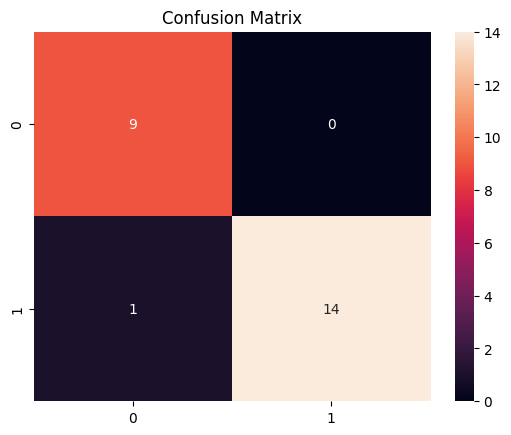

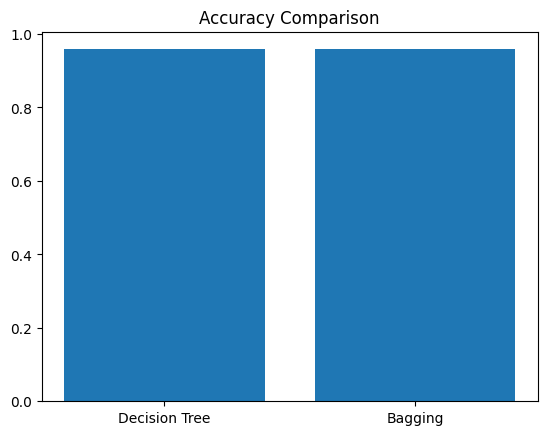

In [8]:
print("SREENIDHI-24BAD114")

from google.colab import files
uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("/content/diabetes_bagging.csv")

print(df.head())
print(df.info())

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt, zero_division=0))

print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))
print(confusion_matrix(y_test, y_pred_bag))
print(classification_report(y_test, y_pred_bag, zero_division=0))

sns.heatmap(confusion_matrix(y_test, y_pred_bag), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

plt.bar(["Decision Tree", "Bagging"], [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_bag)])
plt.title("Accuracy Comparison")
plt.show()

*SCENARIO 2 – (Boosting-AdaBoost, Gradient Boosting)*

Problem Statement: Predict whether a customer will churn.


Dataset: Telco Customer Churn Dataset


Target Variable: Churn (Yes/No)


Input Features: Tenure, Monthly Charges, Contract Type


IN-LAB TASKS

•	Train AdaBoost

•	Train Gradient Boosting

•	Compare performance


Visualization

•	ROC Curve

•	Feature Importance plot



SREENIDHI-24BAD114
Columns in dataset:
 Index(['Tenure', 'MonthlyCharges', 'ContractType', 'InternetService', 'Churn'], dtype='object')

===== MODEL PERFORMANCE =====
AdaBoost Accuracy: 0.94
[[15  0]
 [ 1  0]]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       0.00      0.00      0.00         1

    accuracy                           0.94        16
   macro avg       0.47      0.50      0.48        16
weighted avg       0.88      0.94      0.91        16

Gradient Boosting Accuracy: 1.00
[[15  0]
 [ 0  1]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         1

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16

AdaBoost AUC: 0.93
Gradient Boosting AUC: 1.00


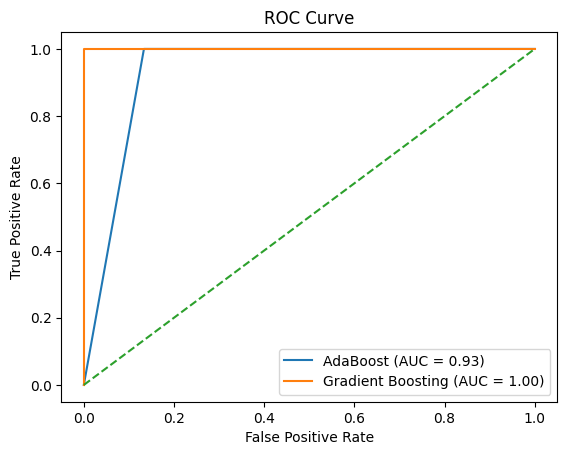

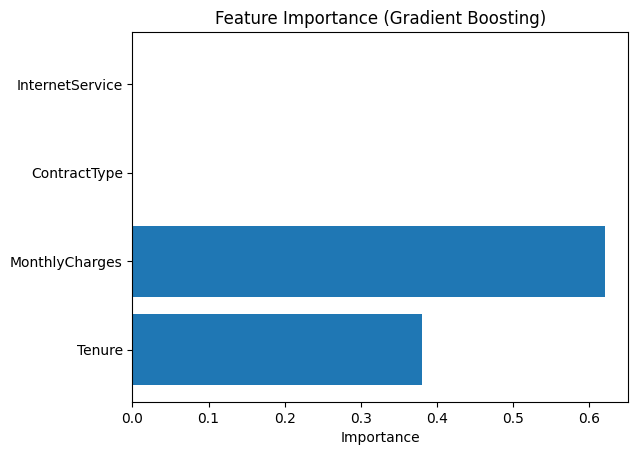


Top Important Features:
           Feature  Importance
1   MonthlyCharges    0.620339
0           Tenure    0.379661
2     ContractType    0.000000
3  InternetService    0.000000


In [7]:
print("SREENIDHI-24BAD114")

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("/content/churn_boosting.csv")
df.columns = df.columns.str.strip()

print("Columns in dataset:\n", df.columns)

if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

df = df.dropna()

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

target_column = None

for col in df.columns:
    if col.lower() == "churn":
        target_column = col

if target_column is None:
    raise Exception("'Churn' column not found. Check dataset column names!")

X = df.drop(target_column, axis=1)
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

ada = AdaBoostClassifier()
gb = GradientBoostingClassifier()

ada.fit(X_train, y_train)
gb.fit(X_train, y_train)

y_pred_ada = ada.predict_proba(X_test)[:, 1]
y_pred_gb = gb.predict_proba(X_test)[:, 1]

fpr1, tpr1, _ = roc_curve(y_test, y_pred_ada)
fpr2, tpr2, _ = roc_curve(y_test, y_pred_gb)

auc1 = auc(fpr1, tpr1)
auc2 = auc(fpr2, tpr2)

y_pred_class_ada = (y_pred_ada > 0.5).astype(int)
y_pred_class_gb = (y_pred_gb > 0.5).astype(int)

acc_ada = accuracy_score(y_test, y_pred_class_ada)
acc_gb = accuracy_score(y_test, y_pred_class_gb)

print("\n===== MODEL PERFORMANCE =====")
print(f"AdaBoost Accuracy: {acc_ada:.2f}")
print(confusion_matrix(y_test, y_pred_class_ada))
print(classification_report(y_test, y_pred_class_ada, zero_division=0))

print(f"Gradient Boosting Accuracy: {acc_gb:.2f}")
print(confusion_matrix(y_test, y_pred_class_gb))
print(classification_report(y_test, y_pred_class_gb, zero_division=0))

print(f"AdaBoost AUC: {auc1:.2f}")
print(f"Gradient Boosting AUC: {auc2:.2f}")

plt.figure()
plt.plot(fpr1, tpr1, label=f"AdaBoost (AUC = {auc1:.2f})")
plt.plot(fpr2, tpr2, label=f"Gradient Boosting (AUC = {auc2:.2f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

importances = gb.feature_importances_

plt.figure()
plt.barh(X.columns, importances)
plt.xlabel("Importance")
plt.title("Feature Importance (Gradient Boosting)")
plt.show()

feature_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop Important Features:")
print(feature_df.head(5))

*SCENARIO 3 – Random Forest*

Problem Statement: Predict whether a person earns >50K salary.


Dataset: Adult Income Dataset


Target Variable: Income (>50K or <=50K)


Input Features: Age, Education, Occupation, Hours-per-week


IN-LAB TASKS

•	Train Random Forest

•	Tune number of trees

•	Evaluate model


Visualization

•	Feature Importance

•	Accuracy vs Number of Trees graph


SREENIDHI-24BAD114


Saving income_random_forest.csv to income_random_forest.csv
   Age  EducationYears  HoursPerWeek  Experience  Income
0   37              12            44          12       0
1   46              19            58          33       1
2   53              10            54          24       0
3   46              11            22           6       0
4   36              17            56           3       1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             120 non-null    int64
 1   EducationYears  120 non-null    int64
 2   HoursPerWeek    120 non-null    int64
 3   Experience      120 non-null    int64
 4   Income          120 non-null    int64
dtypes: int64(5)
memory usage: 4.8 KB
None
Trees: 10 Accuracy: 1.0
[[18  0]
 [ 0  6]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        1

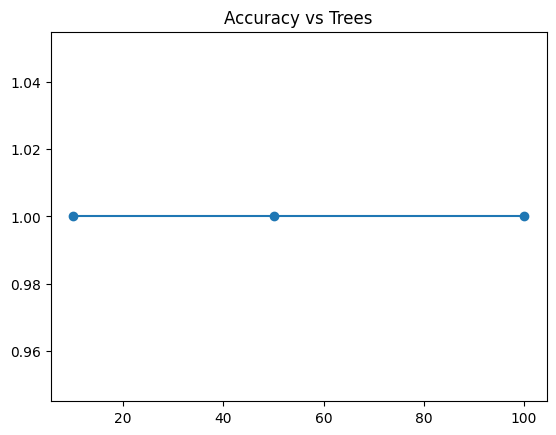

Final Model Accuracy: 1.0
[[18  0]
 [ 0  6]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00         6

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



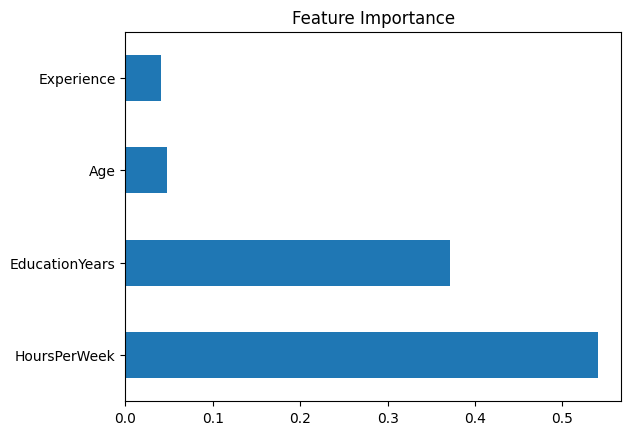

In [3]:
print("SREENIDHI-24BAD114")

from google.colab import files
uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("/content/income_random_forest.csv")

print(df.head())
print(df.info())

if df["Income"].dtype == "object":
    df["Income"] = df["Income"].map({">50K":1, "<=50K":0})

X = pd.get_dummies(df.drop("Income", axis=1))
y = df["Income"]

X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

trees = [10, 50, 100]
acc = []

for t in trees:
    model = RandomForestClassifier(n_estimators=t, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    a = accuracy_score(y_test, y_pred)
    print("Trees:", t, "Accuracy:", a)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    acc.append(a)

plt.plot(trees, acc, marker='o')
plt.title("Accuracy vs Trees")
plt.show()

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred_final = model.predict(X_test)
print("Final Model Accuracy:", accuracy_score(y_test, y_pred_final))
print(confusion_matrix(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

pd.Series(model.feature_importances_, index=X.columns).nlargest(10).plot(kind='barh')
plt.title("Feature Importance")
plt.show()

*SCENARIO 4 – Stacking*

Problem Statement: Predict heart disease presence.

Dataset: Heart Disease Dataset

Target Variable: Presence of Heart Disease (0/1)

Input Features: Cholesterol, Max Heart Rate, Age

IN-LAB TASKS

•	Train base models (Logistic Regression, SVM, Decision Tree)

•	Combine using StackingClassifier

•	Compare with individual models


Visualization

•	Model comparison bar chart


SREENIDHI-24BAD114


Saving heart_stacking.csv to heart_stacking.csv
   Age  Cholesterol  MaxHeartRate  RestingBP  HeartDisease
0   57          212           189        118             0
1   44          266           155        146             1
2   59          279           168        128             1
3   66          237           123        145             1
4   58          221           125        132             0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Age           120 non-null    int64
 1   Cholesterol   120 non-null    int64
 2   MaxHeartRate  120 non-null    int64
 3   RestingBP     120 non-null    int64
 4   HeartDisease  120 non-null    int64
dtypes: int64(5)
memory usage: 4.8 KB
None
LR Accuracy: 0.8333333333333334
[[ 5  4]
 [ 0 15]]
              precision    recall  f1-score   support

           0       1.00      0.56      0.71         9
    

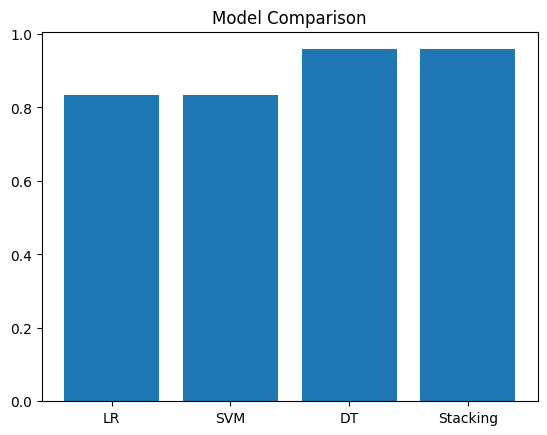

In [2]:
print("SREENIDHI - 24BAD114")

from google.colab import files
uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("/content/heart_stacking.csv")

print(df.head())
print(df.info())

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LogisticRegression(max_iter=1000)
svm = SVC(probability=True)
dt = DecisionTreeClassifier()

stack = StackingClassifier(
    estimators=[('lr', lr), ('svm', svm), ('dt', dt)],
    final_estimator=LogisticRegression()
)

models = {"LR": lr, "SVM": svm, "DT": dt, "Stacking": stack}
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(name, "Accuracy:", acc)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    results[name] = acc

plt.bar(results.keys(), results.values())
plt.title("Model Comparison")
plt.show()

*SCENARIO 5 – SMOTE*

Problem Statement: Detect fraudulent transactions.

Dataset: Credit Card Fraud Detection Dataset

Target Variable: Fraud (0 = Normal, 1 = Fraud)

Input Features: Transaction Amount, Time, PCA features

IN-LAB TASKS

•	Check class imbalance

•	Apply SMOTE

•	Train model before & after SMOTE

•	Compare performance

Visualization

•	Class distribution (Before & After SMOTE)

•	Precision-Recall Curve


Srinidhi24BAD114


Saving fraud_smote.csv to fraud_smote.csv
    Amount   Time  Feature1  Feature2  Fraud
0  3233.38  34595  2.157308 -0.818199      0
1  2783.63  73166  1.561511  0.955305      0
2   923.74  84417 -0.027305 -1.418366      0
3  2214.14  11139 -0.643518 -0.466037      0
4   444.75  37847  0.021272 -0.529053      0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Amount    120 non-null    float64
 1   Time      120 non-null    int64  
 2   Feature1  120 non-null    float64
 3   Feature2  120 non-null    float64
 4   Fraud     120 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 4.8 KB
None
Fraud
0    110
1     10
Name: count, dtype: int64


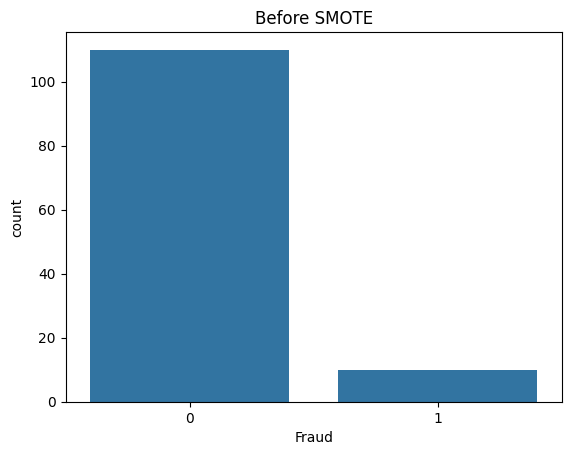

Accuracy Before SMOTE: 0.9166666666666666
[[22  0]
 [ 2  0]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       0.00      0.00      0.00         2

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24

Fraud
0    110
1    110
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


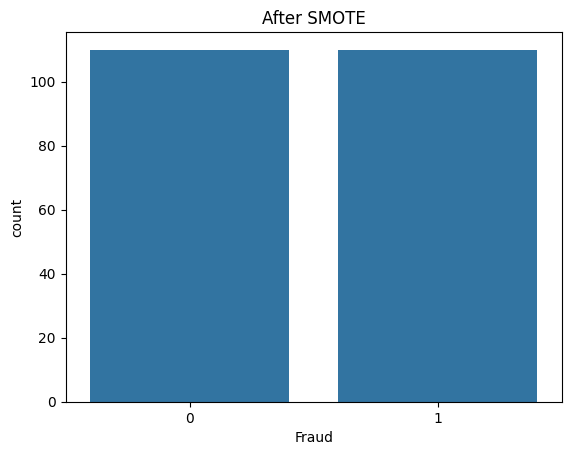

Accuracy After SMOTE: 0.8636363636363636
[[20  4]
 [ 2 18]]
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        24
           1       0.82      0.90      0.86        20

    accuracy                           0.86        44
   macro avg       0.86      0.87      0.86        44
weighted avg       0.87      0.86      0.86        44



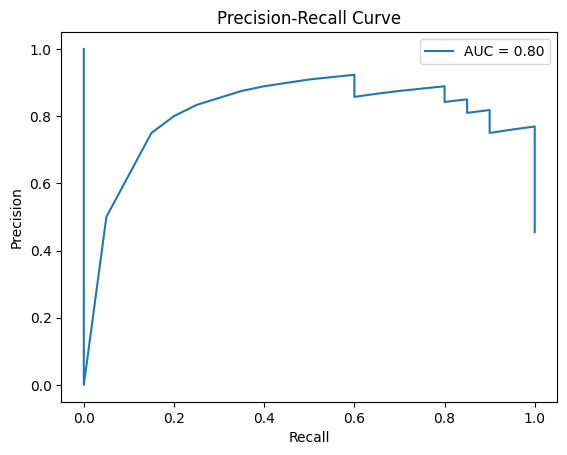

In [1]:
print("SREENIDHI - 24BAD114")

from google.colab import files
uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_curve, auc
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

df = pd.read_csv("/content/fraud_smote.csv")

print(df.head())
print(df.info())

print(df["Fraud"].value_counts())

sns.countplot(x=df["Fraud"])
plt.title("Before SMOTE")
plt.show()

X = df.drop("Fraud", axis=1)
y = df["Fraud"]

X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred_before = model.predict(X_test)

print("Accuracy Before SMOTE:", accuracy_score(y_test, y_pred_before))

print(confusion_matrix(y_test, y_pred_before))
print(classification_report(y_test, y_pred_before))

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print(pd.Series(y_res).value_counts())

sns.countplot(x=y_res)
plt.title("After SMOTE")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

y_pred_after = model.predict(X_test)

print("Accuracy After SMOTE:", accuracy_score(y_test, y_pred_after))

print(confusion_matrix(y_test, y_pred_after))
print(classification_report(y_test, y_pred_after))

y_prob = model.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

plt.plot(recall, precision, label="AUC = %.2f" % pr_auc)
plt.legend()
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()